# Phase 4b — Band T native-unit spatial autocorrelation

Global Moran's I and LISA at native grid for LMR v2.1 and HYDE 3.4.

**LMR**: temperature anomaly + PDSI at 6 epochs, 2° land cells (~5,000), queen contiguity with longitude wrap.
**HYDE**: cropland + grazing_land at 8 epochs, native 5-arcmin (~2.2M land cells). Pilot run first (cropland 1000 CE) before full sweep.

Outputs: , 

In [ ]:
# Cell 2 — imports and setup
import ssl, certifi, urllib.request
_ssl_ctx = ssl.create_default_context(cafile=certifi.where())
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=_ssl_ctx))
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import libpysal.weights as lps_w
from esda.moran import Moran, Moran_Local
from pathlib import Path
import sys, time as _time, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="invalid value encountered")

sys.path.insert(0, "/Users/karlg/Documents/repos/_cedop")
from scripts.shared.db_utils import db_connect

%matplotlib inline

SEED = 42
N_PERM = 999

LMR_DIR = Path("/Users/karlg/Documents/repos/_cedop/data/lmr_v2.1")
OUT_DIR  = Path("/Users/karlg/Documents/repos/_cedop/output/edop/spatial")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output:", OUT_DIR)

In [2]:
# Cell 3 — epoch definitions (same as 4a)
LMR_EPOCHS = [
    ("0 CE (early-LMR)",  0,    49),
    ("1000 CE",           950,  1049),
    ("1500 CE",           1450, 1549),
    ("1900 CE",           1850, 1949),
    ("MCA 950–1250",      950,  1250),
    ("LIA 1450–1850",     1450, 1850),
]
LMR_SLUGS = ["0ce", "1000ce", "1500ce", "1900ce", "mca", "lia"]

HYDE_EPOCHS = [
    (2,   "8000 BCE"),
    (6,   "4000 BCE"),
    (9,   "1000 BCE"),
    (10,  "0 CE"),
    (20,  "1000 CE"),
    (25,  "1500 CE"),
    (47,  "1900 CE"),
    (102, "2000 CE"),
]
print("Epochs defined.")

Epochs defined.


In [3]:
# Cell 4 — load LMR data from DB and reshape to 3D grid
# Replicates 4a Cells 4–6 in a single cell for self-contained notebook.
t0 = _time.time()

ds = nc.Dataset(LMR_DIR / "pdsi_MCruns_ensemble_mean_LMRv2.1.nc")
time_var = ds.variables["time"]
import warnings as _w
with _w.catch_warnings():
    _w.simplefilter("ignore")
    times = nc.num2date(time_var[:], time_var.units, has_year_zero=True)
LMR_YEARS = np.array([t.year for t in times])
ds.close()

conn = db_connect()
lmr_df = pd.read_sql(
    "SELECT lat, lon, pdsi, air FROM temporal.lmr_climate ORDER BY lat DESC, lon ASC",
    conn)
conn.close()

pdsi_all = np.array(lmr_df["pdsi"].tolist(), dtype=np.float32)
air_all  = np.array(lmr_df["air"].tolist(),  dtype=np.float32)

lats_lmr = np.sort(lmr_df["lat"].unique())[::-1]   # 91 values, 90→-90
lons_lmr = np.sort(lmr_df["lon"].unique())          # 180 values, 0→358
NLAT, NLON = len(lats_lmr), len(lons_lmr)

pdsi_grid = pdsi_all.reshape(NLAT, NLON, len(LMR_YEARS))
air_grid  = air_all.reshape(NLAT, NLON, len(LMR_YEARS))

print(f"LMR loaded in {_time.time()-t0:.1f}s  |  grid {NLAT}×{NLON}  |  years {LMR_YEARS[0]}–{LMR_YEARS[-1]}")

LMR loaded in 17.2s  |  grid 91×180  |  years 0–1998


In [4]:
# Cell 5 — compute LMR epoch anomaly slices (same as 4a Cell 7)
air_full  = np.nanmean(air_grid,  axis=2)
pdsi_full = np.nanmean(pdsi_grid, axis=2)

def epoch_anomaly(grid3d, full_mean, year_lo, year_hi):
    mask = (LMR_YEARS >= year_lo) & (LMR_YEARS <= year_hi)
    return np.nanmean(grid3d[:, :, mask], axis=2) - full_mean, int(mask.sum())

air_epochs, pdsi_epochs = [], []
for label, yr_lo, yr_hi in LMR_EPOCHS:
    a, na = epoch_anomaly(air_grid,  air_full,  yr_lo, yr_hi)
    p, _  = epoch_anomaly(pdsi_grid, pdsi_full, yr_lo, yr_hi)
    air_epochs.append(a)
    pdsi_epochs.append(p)
    print(f"{label} ({na} steps): air={np.nanmean(a):.4f} K  pdsi={np.nanmean(p):.4f}")

print("Epoch anomaly slices ready.")

0 CE (early-LMR) (51 steps): air=0.0712 K  pdsi=-0.0031
1000 CE (100 steps): air=-0.0226 K  pdsi=0.0062
1500 CE (101 steps): air=-0.0913 K  pdsi=0.0024
1900 CE (100 steps): air=-0.0425 K  pdsi=-0.0152
MCA 950–1250 (301 steps): air=-0.0372 K  pdsi=0.0033
LIA 1450–1850 (402 steps): air=-0.1142 K  pdsi=-0.0013
Epoch anomaly slices ready.


In [5]:
# Cell 6 — LMR land mask: ~5,000 cells that contain at least one L8 basin centroid
# Snap each basin centroid to the nearest 2° LMR cell (lat: 90→-90 step -2; lon: 0→358 step 2).
t0 = _time.time()
conn = db_connect()
basin_pts = pd.read_sql("""
    SELECT ST_X(ST_Centroid(geom)) AS lon,
           ST_Y(ST_Centroid(geom)) AS lat
    FROM   public.basin08
""", conn)
conn.close()
print(f"Basin centroids loaded: {len(basin_pts):,}  in {_time.time()-t0:.1f}s")

# Convert centroid lon from −180..180 → 0..358 to match LMR convention
basin_lon = basin_pts["lon"].values % 360   # −5° → 355°, 0° → 0°, etc.
basin_lat = basin_pts["lat"].values

# Snap to nearest LMR grid point
# LMR lats: 90, 88, ..., −90  →  row = (90 − lat) / 2  (round to nearest integer)
# LMR lons: 0, 2, ..., 358    →  col = lon / 2
snap_row = np.clip(np.round((90 - basin_lat) / 2).astype(int), 0, NLAT - 1)
snap_col = np.clip(np.round(basin_lon       / 2).astype(int), 0, NLON - 1)

# Boolean land mask on the 91×180 grid
land_mask_lmr = np.zeros((NLAT, NLON), dtype=bool)
land_mask_lmr[snap_row, snap_col] = True

n_land_lmr = int(land_mask_lmr.sum())
print(f"LMR land cells (L8-bearing): {n_land_lmr:,}")

# Cell-index arrays for land cells (used later to extract values)
lmr_land_rows, lmr_land_cols = np.where(land_mask_lmr)
print(f"Row range: {lmr_land_rows.min()}–{lmr_land_rows.max()}  "
      f"(lat {lats_lmr[lmr_land_rows.max()]}°–{lats_lmr[lmr_land_rows.min()]}°)")

Basin centroids loaded: 190,675  in 1.5s
LMR land cells (L8-bearing): 4,924
Row range: 3–73  (lat -56.0°–84.0°)


In [6]:
# Cell 7 — build LMR queen weights (lat2W + longitude wrap + subset to land cells)
# lat2W builds queen contiguity for a full NLAT×NLON regular grid.
# After construction: (1) add lon-wrap edges (col 0 ↔ col 179), (2) subset to land cells.
t0 = _time.time()

w_full = lps_w.lat2W(NLAT, NLON, rook=False)   # full 91×180 = 16,380-cell queen W

# Add longitude wrap: cell (i, 0) ↔ cell (i, NLON-1) for all rows i,
# plus diagonal wrap cells (i±1, 0) ↔ (i∓1, NLON-1).
for i in range(NLAT):
    left  = i * NLON + 0
    right = i * NLON + (NLON - 1)
    # cardinal wrap
    if right not in w_full.neighbors[left]:
        w_full.neighbors[left].append(right)
        w_full.weights[left].append(1.0)
    if left not in w_full.neighbors[right]:
        w_full.neighbors[right].append(left)
        w_full.weights[right].append(1.0)
    # diagonal wraps
    for di in [-1, 1]:
        ni = i + di
        if 0 <= ni < NLAT:
            diag_left  = ni * NLON + 0
            diag_right = ni * NLON + (NLON - 1)
            if diag_right not in w_full.neighbors[left]:
                w_full.neighbors[left].append(diag_right)
                w_full.weights[left].append(1.0)
            if diag_left not in w_full.neighbors[right]:
                w_full.neighbors[right].append(diag_left)
                w_full.weights[right].append(1.0)

# Build mapping: full-grid flat index → land-cell index (-1 if ocean)
full_to_land = np.full(NLAT * NLON, -1, dtype=np.int32)
land_flat_idx = lmr_land_rows * NLON + lmr_land_cols
full_to_land[land_flat_idx] = np.arange(n_land_lmr)

# Subset: keep only land cells, remap neighbor IDs to land-cell IDs
land_neighbors = {}
land_weights   = {}
for k, flat_k in enumerate(land_flat_idx):
    nbr_land = [full_to_land[nb] for nb in w_full.neighbors[flat_k]
                if full_to_land[nb] >= 0]
    land_neighbors[k] = nbr_land
    land_weights[k]   = [1.0] * len(nbr_land)

w_lmr = lps_w.W(land_neighbors, land_weights, silence_warnings=True)
w_lmr.transform = "r"   # row-standardize

print(f"LMR queen W built in {_time.time()-t0:.1f}s")
print(f"  n={w_lmr.n}  mean_neighbors={w_lmr.mean_neighbors:.2f}  islands={w_lmr.islands}")

LMR queen W built in 0.3s
  n=4924  mean_neighbors=7.18  islands=[10, 61, 62, 63, 64, 69, 262, 440, 1269, 1436, 1759, 1760, 2974, 3140, 3291, 3363, 3494, 3498, 3546, 3676, 3737, 3738, 4052, 4068, 4212, 4213, 4350, 4476, 4510, 4721, 4760, 4795, 4901, 4907]


In [7]:
# Cell 8 — LMR Moran's I: temperature and PDSI across all epochs
# Anomaly fields are symmetric around zero → log not applicable; use raw values.
# Extract land-cell vector from each epoch's 2D array, run Moran, collect results.

lmr_moran_rows = []

def run_lmr_moran(epoch_arrays, var_name):
    for arr, (label, _, _), slug in zip(epoch_arrays, LMR_EPOCHS, LMR_SLUGS):
        y = arr[lmr_land_rows, lmr_land_cols].astype(float)
        np.random.seed(SEED)
        mi = Moran(y, w_lmr, permutations=N_PERM)
        lmr_moran_rows.append({
            "dataset":          "LMR",
            "variable":         var_name,
            "epoch":            label,
            "epoch_slug":       slug,
            "scale":            "2deg_land",
            "I_raw":            round(mi.I, 6),
            "I_log":            None,
            "transform_used":   "raw",
            "p_value":          round(mi.p_sim, 4),
            "non_zero_fraction": None,   # not applicable for anomaly fields
        })
        print(f"  {label}: I={mi.I:.4f}  p={mi.p_sim:.4f}")

print("=== LMR temperature anomaly ===")
run_lmr_moran(air_epochs, "temperature")
print("\n=== LMR PDSI anomaly ===")
run_lmr_moran(pdsi_epochs, "pdsi")

print(f"\n{len(lmr_moran_rows)} Moran's I results collected.")

  LIA 1450–1850: I=0.8789  p=0.0010

12 Moran's I results collected.


In [8]:
# Cell 9 — LMR LISA: temperature and PDSI across all epochs
# Classify each land cell: HH, LL, HL, LH, NS (p >= 0.05).
LISA_LABELS = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}

lmr_lisa_rows = []

def run_lmr_lisa(epoch_arrays, var_name):
    for arr, (label, _, _), slug in zip(epoch_arrays, LMR_EPOCHS, LMR_SLUGS):
        y = arr[lmr_land_rows, lmr_land_cols].astype(float)
        np.random.seed(SEED)
        lisa = Moran_Local(y, w_lmr, permutations=N_PERM, seed=SEED)
        for k in range(n_land_lmr):
            lmr_lisa_rows.append({
                "dataset":   "LMR",
                "variable":  var_name,
                "epoch":     label,
                "epoch_slug": slug,
                "cell_id":   int(land_flat_idx[k]),
                "lat":       float(lats_lmr[lmr_land_rows[k]]),
                "lon":       float(lons_lmr[lmr_land_cols[k]]),
                "lisa_class": LISA_LABELS.get(lisa.q[k], "NS") if lisa.p_sim[k] < 0.05 else "NS",
                "p_value":   round(float(lisa.p_sim[k]), 4),
            })
        counts = pd.Series([
            LISA_LABELS.get(lisa.q[k], "NS") if lisa.p_sim[k] < 0.05 else "NS"
            for k in range(n_land_lmr)
        ]).value_counts()
        print(f"  {label}: {dict(counts)}")

print("=== LMR temperature LISA ===")
run_lmr_lisa(air_epochs, "temperature")
print("\n=== LMR PDSI LISA ===")
run_lmr_lisa(pdsi_epochs, "pdsi")

print(f"\n{len(lmr_lisa_rows):,} LISA rows collected.")

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


In [9]:
print(len(lmr_lisa_rows))
print(sorted(set((r['variable'], r['epoch']) for r in lmr_lisa_rows)))

59088
[('pdsi', '0 CE (early-LMR)'), ('pdsi', '1000 CE'), ('pdsi', '1500 CE'), ('pdsi', '1900 CE'), ('pdsi', 'LIA 1450–1850'), ('pdsi', 'MCA 950–1250'), ('temperature', '0 CE (early-LMR)'), ('temperature', '1000 CE'), ('temperature', '1500 CE'), ('temperature', '1900 CE'), ('temperature', 'LIA 1450–1850'), ('temperature', 'MCA 950–1250')]


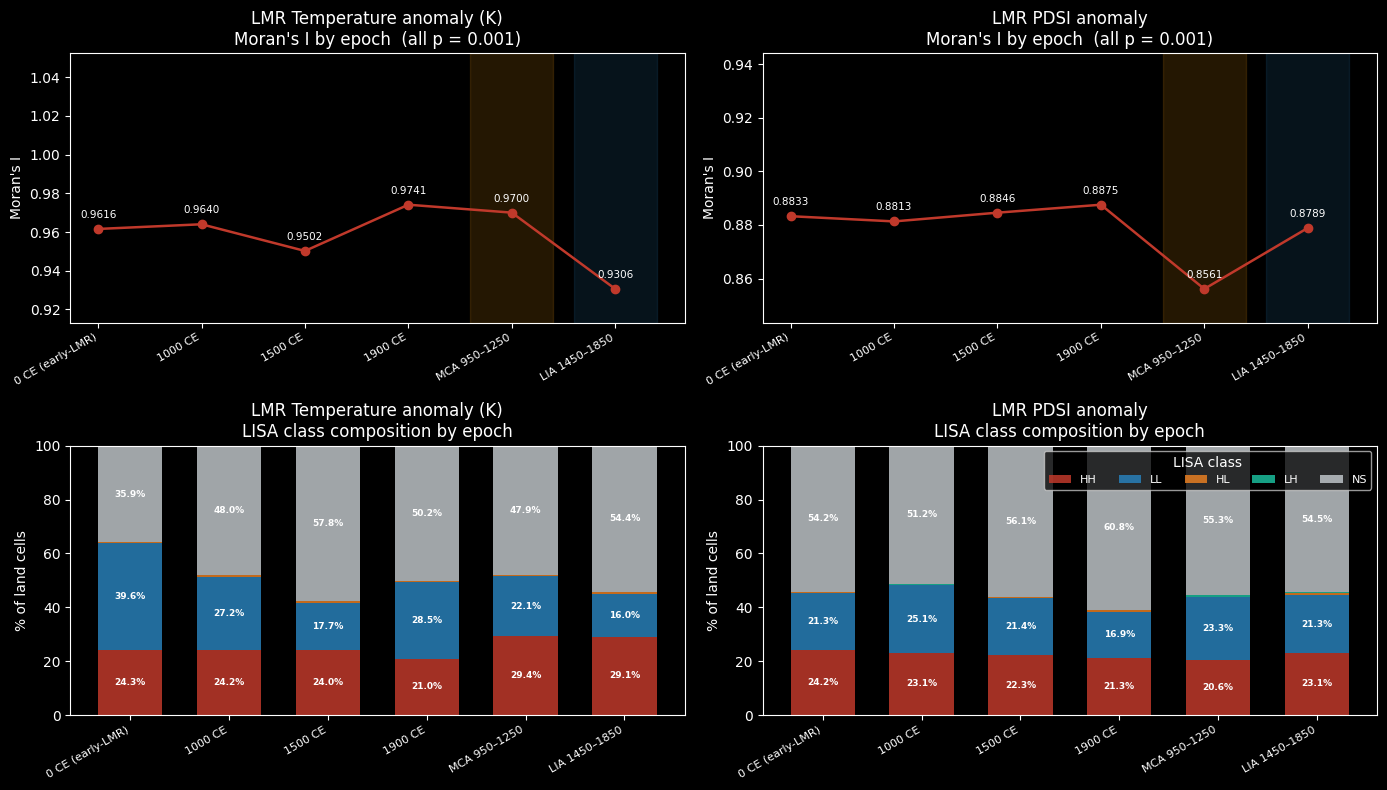

In [12]:
# Cell 10 — LMR trajectory + LISA composition plots (2×2)
# Top row:    Moran's I line plot per variable, y-axis zoomed, values annotated.
# Bottom row: 100% stacked bar of LISA class composition per epoch.
EPOCH_ORDER  = [lbl for lbl, _, _ in LMR_EPOCHS]
LISA_CLASSES = ["HH", "LL", "HL", "LH", "NS"]
LISA_COLORS  = {"HH": "#c0392b", "LL": "#2980b9", "HL": "#e67e22", "LH": "#1abc9c", "NS": "#bdc3c7"}

# Pre-compute LISA composition from lmr_lisa_rows via pandas
_df_ll = pd.DataFrame(lmr_lisa_rows)
_lisa_pct = (
    _df_ll.groupby(["variable", "epoch", "lisa_class"])
          .size()
          .div(n_land_lmr / 100)          # → percent of land cells
          .reset_index(name="pct")
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (var_name, title) in enumerate([
        ("temperature", "Temperature anomaly (K)"),
        ("pdsi",        "PDSI anomaly")]):

    # ── Top: I trajectory ──────────────────────────────────────────────
    ax_i = axes[0, col]
    rows = [r for r in lmr_moran_rows if r["variable"] == var_name]
    Is     = [r["I_raw"] for r in rows]
    labels = [r["epoch"] for r in rows]

    ax_i.plot(range(len(rows)), Is, "o-", color="#c0392b", linewidth=1.8, markersize=6)
    for xi, I_val in enumerate(Is):
        ax_i.annotate(f"{I_val:.4f}", (xi, I_val),
                      textcoords="offset points", xytext=(0, 8),
                      ha="center", fontsize=7.5)
    # MCA / LIA shading
    for xi, (lbl, _, _) in enumerate(LMR_EPOCHS):
        if "MCA" in lbl:
            ax_i.axvspan(xi - 0.4, xi + 0.4, color="#f39c12", alpha=0.15)
        if "LIA" in lbl:
            ax_i.axvspan(xi - 0.4, xi + 0.4, color="#2980b9", alpha=0.15)
    # Zoom to actual range with headroom for annotations
    i_min, i_max = min(Is), max(Is)
    span = max(0.02, i_max - i_min)
    ax_i.set_ylim(i_min - span * 0.4, i_max + span * 1.8)
    ax_i.set_xticks(range(len(rows)))
    ax_i.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax_i.set_ylabel("Moran's I")
    ax_i.set_title(f"LMR {title}\nMoran's I by epoch  (all p = 0.001)")

    # ── Bottom: LISA class composition (100% stacked bar) ──────────────
    ax_l = axes[1, col]
    sub = _lisa_pct[_lisa_pct["variable"] == var_name]
    bottom = np.zeros(len(EPOCH_ORDER))
    for cls in LISA_CLASSES:
        vals = np.array([
            sub.loc[(sub["epoch"] == lbl) & (sub["lisa_class"] == cls), "pct"]
               .sum()           # 0 if class absent at that epoch
            for lbl in EPOCH_ORDER
        ])
        bars = ax_l.bar(range(len(EPOCH_ORDER)), vals, bottom=bottom,
                        color=LISA_COLORS[cls], label=cls, alpha=0.85, width=0.65)
        # Label segments wide enough to read
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 2.5:
                ax_l.text(xi, b + v / 2, f"{v:.1f}%",
                          ha="center", va="center", fontsize=6.5,
                          color="white", fontweight="bold")
        bottom += vals

    ax_l.set_xticks(range(len(EPOCH_ORDER)))
    ax_l.set_xticklabels(EPOCH_ORDER, rotation=30, ha="right", fontsize=8)
    ax_l.set_ylabel("% of land cells")
    ax_l.set_title(f"LMR {title}\nLISA class composition by epoch")
    ax_l.set_ylim(0, 100)
    if col == 1:
        ax_l.legend(loc="upper right", fontsize=8, ncol=5,
                    framealpha=0.75, title="LISA class")

plt.tight_layout()
plt.savefig(OUT_DIR / "lmr_moran_trajectory.png", dpi=150, bbox_inches="tight")
print("Saved lmr_moran_trajectory.png")

In [13]:
# Cell 11 — HYDE: load data from DB (same two variables, all epochs)
t0 = _time.time()
crop_cols = ", ".join([f"cropland[{si+1}] AS crop_{si}" for si, _ in HYDE_EPOCHS])
graz_cols = ", ".join([f"grazing[{si+1}]  AS graz_{si}" for si, _ in HYDE_EPOCHS])
conn = db_connect()
hyde_df = pd.read_sql(f"""
    SELECT ST_X(ST_Centroid(geom)) AS lon,
           ST_Y(ST_Centroid(geom)) AS lat,
           area_km2, {crop_cols}, {graz_cols}
    FROM temporal.hyde_cells
""", conn)
conn.close()
print(f"HYDE loaded: {len(hyde_df):,} rows in {_time.time()-t0:.1f}s")

# Rasterize to 2160×4320 fraction arrays (same as 4a Cell 13)
HYDE_NROW, HYDE_NCOL = 2160, 4320
lons_h = hyde_df["lon"].values
lats_h = hyde_df["lat"].values
area_h = hyde_df["area_km2"].values
row_idx = np.clip(np.round((90.0  - lats_h) * 12).astype(int), 0, HYDE_NROW - 1)
col_idx = np.clip(np.round((lons_h + 180.0) * 12).astype(int), 0, HYDE_NCOL - 1)
area_raster = np.full((HYDE_NROW, HYDE_NCOL), np.nan, dtype=np.float32)
area_raster[row_idx, col_idx] = area_h

def rasterize_hyde(col_prefix):
    grids = {}
    for si, _ in HYDE_EPOCHS:
        vals = np.where(hyde_df[f"{col_prefix}_{si}"].values < 0, 0.0,
                        hyde_df[f"{col_prefix}_{si}"].values).astype(np.float32)
        raster = np.full((HYDE_NROW, HYDE_NCOL), np.nan, dtype=np.float32)
        raster[row_idx, col_idx] = vals
        grids[si] = np.clip(raster / area_raster, 0.0, 1.0)
    return grids

crop_grids = rasterize_hyde("crop")
graz_grids = rasterize_hyde("graz")
print("Rasterization complete.")

Rasterization complete.


In [14]:
# Cell 12 — HYDE pilot: build land mask and queen weights (TIMED)
# Land mask: cells where area_raster is not NaN (i.e. any cell present in DB).
# Queen contiguity built directly from grid topology — NOT Queen.from_dataframe.
# Vectorized neighbor enumeration: O(n_land) not O(n_land²).

t_mask = _time.time()
hyde_land_mask = ~np.isnan(area_raster)   # True = land cell exists
hyde_land_rows, hyde_land_cols = np.where(hyde_land_mask)
n_hyde_land = len(hyde_land_rows)
print(f"HYDE land cells: {n_hyde_land:,}  (mask built in {_time.time()-t_mask:.1f}s)")

# Fast mapping: (row, col) → land-cell index
hyde_land_idx_2d = np.full((HYDE_NROW, HYDE_NCOL), -1, dtype=np.int32)
hyde_land_idx_2d[hyde_land_rows, hyde_land_cols] = np.arange(n_hyde_land)

t_w = _time.time()
# Queen offsets: 8 directions
offsets_r = np.array([-1, -1, -1,  0,  0,  1,  1,  1], dtype=np.int32)
offsets_c = np.array([-1,  0,  1, -1,  1, -1,  0,  1], dtype=np.int32)

nbrs_dict = {}
for d_r, d_c in zip(offsets_r, offsets_c):
    nbr_r = hyde_land_rows + d_r
    nbr_c = (hyde_land_cols + d_c) % HYDE_NCOL   # longitude wrap
    valid = (nbr_r >= 0) & (nbr_r < HYDE_NROW)
    nbr_idx = np.where(valid, hyde_land_idx_2d[
        np.clip(nbr_r, 0, HYDE_NROW-1), nbr_c], -1)
    for k in range(n_hyde_land):
        if nbr_idx[k] >= 0:
            nbrs_dict.setdefault(k, []).append(int(nbr_idx[k]))

# Fill in any cells with no neighbors (islands)
for k in range(n_hyde_land):
    nbrs_dict.setdefault(k, [])

t_w_build = _time.time()
w_hyde = lps_w.W(nbrs_dict,
                 {k: [1.0] * len(v) for k, v in nbrs_dict.items()},
                 silence_warnings=True)
w_hyde.transform = "r"
t_w_end = _time.time()

print(f"Weight build (neighbor enum): {t_w_build - t_w:.1f}s")
print(f"W object construction:        {t_w_end - t_w_build:.1f}s")
print(f"Total weights build:          {t_w_end - t_w:.1f}s")
print(f"  n={w_hyde.n:,}  mean_neighbors={w_hyde.mean_neighbors:.2f}  islands={len(w_hyde.islands)}")

  n=2,213,836  mean_neighbors=7.88  islands=76


In [15]:
# Cell 13 — HYDE pilot: Moran's I + LISA for cropland 1000 CE (TIMED)
# Pilot variable/epoch: cropland at step 20 (1000 CE), non-zero fraction 26.1%.
# Log-transform: HYDE fractions are heavily right-skewed → log1p applied if skew > 5.
import scipy.stats as stats

PILOT_SI = 20   # 1000 CE
pilot_grid = crop_grids[PILOT_SI]
pilot_y_raw = pilot_grid[hyde_land_rows, hyde_land_cols].astype(float)
pilot_y_raw = np.nan_to_num(pilot_y_raw, nan=0.0)

nz_frac = (pilot_y_raw > 0).mean()
skew_raw = float(stats.skew(pilot_y_raw))
print(f"Cropland 1000 CE: n={len(pilot_y_raw):,}  non-zero={nz_frac:.3f}  skew={skew_raw:.2f}")

# Log-transform if skew > 5
if skew_raw > 5:
    pilot_y = np.log1p(pilot_y_raw)
    transform_used = "log1p"
    skew_log = float(stats.skew(pilot_y))
    print(f"Skew > 5 → log1p applied  (log skew={skew_log:.2f})")
else:
    pilot_y = pilot_y_raw
    transform_used = "raw"
    print("Skew <= 5 → raw values used")

# --- Moran's I ---
t_mi = _time.time()
np.random.seed(SEED)
mi_pilot = Moran(pilot_y, w_hyde, permutations=N_PERM)
t_mi_end = _time.time()
print(f"\nMoran's I:  I={mi_pilot.I:.4f}  p={mi_pilot.p_sim:.4f}  ({t_mi_end - t_mi:.1f}s)")

# --- LISA ---
t_lisa = _time.time()
np.random.seed(SEED)
lisa_pilot = Moran_Local(pilot_y, w_hyde, permutations=N_PERM, seed=SEED)
t_lisa_end = _time.time()
print(f"LISA:       ({t_lisa_end - t_lisa:.1f}s)")

pilot_classes = [
    LISA_LABELS.get(lisa_pilot.q[k], "NS") if lisa_pilot.p_sim[k] < 0.05 else "NS"
    for k in range(n_hyde_land)
]
print("LISA counts:", dict(pd.Series(pilot_classes).value_counts()))

print(f"\n=== PILOT TIMING SUMMARY ===")
print(f"  Weights build:  (see Cell 12)")
print(f"  Moran's I:      {t_mi_end - t_mi:.1f}s")
print(f"  LISA:           {t_lisa_end - t_lisa:.1f}s")

LISA counts: {'LL': np.int64(1309092), 'NS': np.int64(754685), 'HH': np.int64(126234), 'LH': np.int64(22883), 'HL': np.int64(942)}

=== PILOT TIMING SUMMARY ===
  Weights build:  (see Cell 12)
  Moran's I:      31.1s
  LISA:           2246.6s


In [16]:
# Cell 14 — HYDE tractability assessment
t_mi_per_epoch  = t_mi_end   - t_mi
t_lis_per_epoch = t_lisa_end - t_lisa
t_full_moran    = t_mi_per_epoch  * 2 * 7   # 2 vars × 7 non-degenerate epochs (s)
t_full_w_lisa   = (t_mi_per_epoch + t_lis_per_epoch) * 2 * 7

print("=== TRACTABILITY ASSESSMENT ===")
print(f"  Pilot Moran's I (cropland 1000 CE): {t_mi_per_epoch:.1f}s")
print(f"  Pilot LISA      (cropland 1000 CE): {t_lis_per_epoch:.1f}s")
print(f"  Projected Moran's I sweep (2 vars × 7 epochs): {t_full_moran/60:.1f} min")
print(f"  Projected full sweep incl. LISA:                {t_full_w_lisa/3600:.1f} h")
print()
print("DECISION: Moran's I sweep only — LISA intractable at 2.2M cells × 999 perms.")
print("  Pilot LISA (cropland 1000 CE) retained for structural characterization.")

DEGENERATE_SIS  = {2}   # 8000 BCE: non-zero < 5% for both variables
HYDE_RUN_EPOCHS = [(si, lbl) for si, lbl in HYDE_EPOCHS if si not in DEGENERATE_SIS]
print(f"\n  Epochs to run: {[lbl for _, lbl in HYDE_RUN_EPOCHS]}")

=== TRACTABILITY ASSESSMENT ===
  Pilot Moran's I (cropland 1000 CE): 31.1s
  Pilot LISA      (cropland 1000 CE): 2246.6s
  Projected Moran's I sweep (2 vars × 7 epochs): 7.2 min
  Projected full sweep incl. LISA:                8.9 h

DECISION: Moran's I sweep only — LISA intractable at 2.2M cells × 999 perms.
  Pilot LISA (cropland 1000 CE) retained for structural characterization.

  Epochs to run: ['4000 BCE', '1000 BCE', '0 CE', '1000 CE', '1500 CE', '1900 CE', '2000 CE']


In [17]:
# Cell 15 — HYDE Moran's I sweep (all non-degenerate epochs × 2 variables)
# LISA dropped: 2,247s per epoch at 2.2M cells is intractable for a full sweep.
# Pilot LISA result (cropland 1000 CE) retained in memory; summarised in Cell 17.
import scipy.stats as stats

hyde_moran_rows = []

# Include pilot result
hyde_moran_rows.append({
    "dataset": "HYDE", "variable": "cropland", "epoch": "1000 CE",
    "epoch_slug": "1000ce", "scale": "5arcmin",
    "I_raw": None,
    "I_log": round(float(mi_pilot.I), 6),
    "transform_used": transform_used,
    "p_value": round(float(mi_pilot.p_sim), 4),
    "non_zero_fraction": round(nz_frac, 4),
})
print(f"  cropland 1000 CE (pilot): I={mi_pilot.I:.4f}  p={mi_pilot.p_sim:.4f}"
      f"  nz={nz_frac:.3f}  [log1p]")

def run_hyde_moran(grids, var_name):
    for si, label in HYDE_RUN_EPOCHS:
        if label == "1000 CE" and var_name == "cropland":
            continue   # pilot already added
        slug = label.lower().replace(" ", "").replace("-", "")
        y_raw = grids[si][hyde_land_rows, hyde_land_cols].astype(float)
        y_raw = np.nan_to_num(y_raw, nan=0.0)
        nz = (y_raw > 0).mean()
        if nz < 0.05:
            print(f"  {var_name} {label}: DEGENERATE ({nz:.3f} non-zero) — skipped")
            hyde_moran_rows.append({
                "dataset": "HYDE", "variable": var_name, "epoch": label,
                "epoch_slug": slug, "scale": "5arcmin",
                "I_raw": None, "I_log": None, "transform_used": "degenerate",
                "p_value": None, "non_zero_fraction": round(nz, 4),
            })
            continue

        skew_r = float(stats.skew(y_raw))
        y, tr = (np.log1p(y_raw), "log1p") if skew_r > 5 else (y_raw, "raw")

        t0 = _time.time()
        np.random.seed(SEED)
        mi = Moran(y, w_hyde, permutations=N_PERM)
        elapsed = _time.time() - t0

        I_raw = round(float(mi.I), 6) if tr == "raw"   else None
        I_log = round(float(mi.I), 6) if tr == "log1p" else None
        hyde_moran_rows.append({
            "dataset": "HYDE", "variable": var_name, "epoch": label,
            "epoch_slug": slug, "scale": "5arcmin",
            "I_raw": I_raw, "I_log": I_log, "transform_used": tr,
            "p_value": round(float(mi.p_sim), 4),
            "non_zero_fraction": round(nz, 4),
        })
        I_display = I_log if I_log is not None else I_raw
        print(f"  {var_name} {label}: I={I_display:.4f}  p={mi.p_sim:.4f}"
              f"  nz={nz:.3f}  {tr}  ({elapsed:.1f}s)")

print("=== HYDE cropland Moran's I ===")
run_hyde_moran(crop_grids, "cropland")
print("\n=== HYDE grazing Moran's I ===")
run_hyde_moran(graz_grids, "grazing")
print(f"\nMoran rows collected: {len(hyde_moran_rows)}")

  grazing 2000 CE: I=0.9287  p=0.0010  nz=0.588  raw  (26.8s)

Moran rows collected: 14


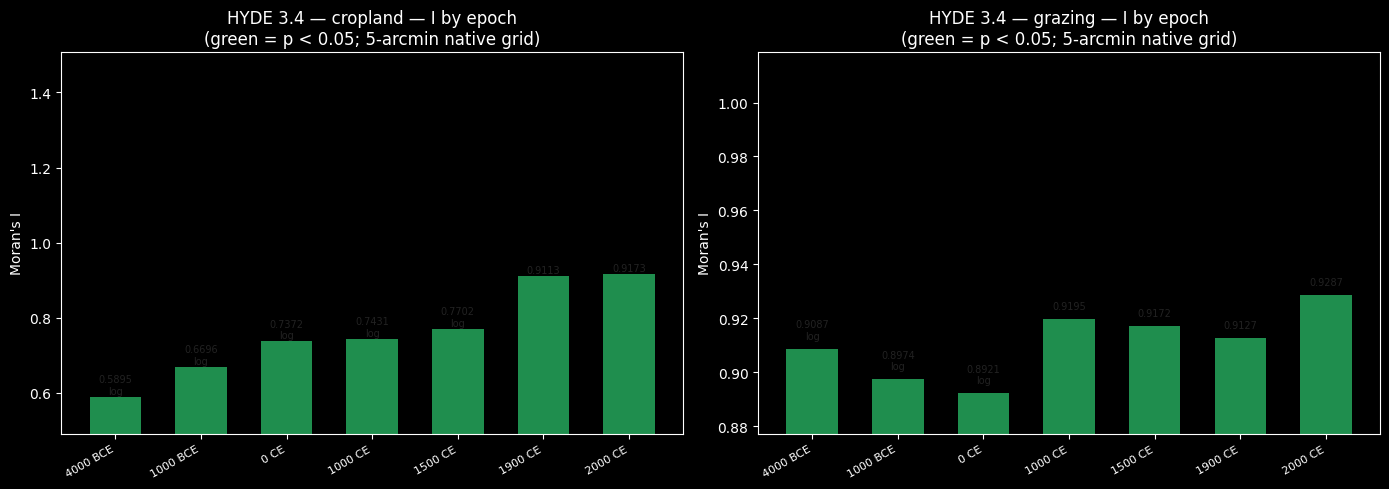

In [19]:
# Cell 16 — HYDE trajectory plots: I vs epoch for cropland and grazing
# Epochs sorted chronologically; y-axis zoomed; values annotated.
HYDE_CHRON = [lbl for _, lbl in HYDE_EPOCHS if _ not in DEGENERATE_SIS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var_name in zip(axes, ["cropland", "grazing"]):
    row_map = {r["epoch"]: r for r in hyde_moran_rows
               if r["variable"] == var_name and r["transform_used"] != "degenerate"}
    ordered = [row_map[lbl] for lbl in HYDE_CHRON if lbl in row_map]

    Is     = [r["I_log"] if r["I_log"] is not None else r["I_raw"] for r in ordered]
    ps     = [r["p_value"] for r in ordered]
    labels = [r["epoch"] for r in ordered]
    trs    = [r["transform_used"] for r in ordered]

    x = range(len(ordered))
    colors = ["#27ae60" if p < 0.05 else "#aaaaaa" for p in ps]
    ax.bar(x, Is, color=colors, alpha=0.82, width=0.6)

    # Value + transform annotations
    for xi, (I_val, tr) in enumerate(zip(Is, trs)):
        suffix = "\nlog" if tr == "log1p" else ""
        ax.text(xi, I_val + 0.003, f"{I_val:.4f}{suffix}",
                ha="center", va="bottom", fontsize=7, color="#222")

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Moran's I")
    ax.set_title(f"HYDE 3.4 — {var_name} — I by epoch\n"
                 "(green = p < 0.05; 5-arcmin native grid)")

    i_min, i_max = min(Is), max(Is)
    span = max(0.05, i_max - i_min)
    ax.set_ylim(max(0, i_min - span * 0.3), i_max + span * 1.8)

plt.tight_layout()
plt.savefig(OUT_DIR / "hyde_moran_trajectory.png", dpi=150, bbox_inches="tight")
print("Saved hyde_moran_trajectory.png")

In [20]:
# Cell 17 — write outputs
# band_t_native_moran.csv        — all Moran's I results (LMR + HYDE)
# band_t_native_lmr_lisa.parquet — LMR LISA cell-level results (59,088 rows)
# band_t_native_hyde_lisa_pilot.csv — HYDE pilot LISA summary only (cropland 1000 CE)
# Note: HYDE full LISA sweep not run — intractable (~2,247s × 14 epoch-variable combinations)

# ── Moran's I table ────────────────────────────────────────────────────
all_moran = lmr_moran_rows + hyde_moran_rows
df_moran = pd.DataFrame(all_moran, columns=[
    "dataset", "variable", "epoch", "epoch_slug", "scale",
    "I_raw", "I_log", "transform_used", "p_value", "non_zero_fraction"
])
moran_path = OUT_DIR / "band_t_native_moran.csv"
df_moran.to_csv(moran_path, index=False)
print(f"Saved {moran_path}  ({len(df_moran)} rows)")
print(df_moran.to_string(index=False))

# ── LMR LISA (full cell-level, ~5k cells × 12 epoch-variable combos) ──
df_lmr_lisa = pd.DataFrame(lmr_lisa_rows, columns=[
    "dataset", "variable", "epoch", "epoch_slug",
    "cell_id", "lat", "lon", "lisa_class", "p_value"
])
lmr_lisa_path = OUT_DIR / "band_t_native_lmr_lisa.parquet"
df_lmr_lisa.to_parquet(lmr_lisa_path, index=False)
print(f"\nSaved {lmr_lisa_path}  ({len(df_lmr_lisa):,} rows)")

# ── HYDE pilot LISA — class-count summary (not cell-level) ─────────────
_ps = pd.Series(pilot_classes)
pilot_lisa_summary = pd.DataFrame([
    {"variable": "cropland", "epoch": "1000 CE", "transform": "log1p",
     "lisa_class": cls,
     "count":    int((_ps == cls).sum()),
     "pct_land": round(float((_ps == cls).mean() * 100), 2)}
    for cls in ["HH", "LL", "HL", "LH", "NS"]
])
pilot_lisa_path = OUT_DIR / "band_t_native_hyde_lisa_pilot.csv"
pilot_lisa_summary.to_csv(pilot_lisa_path, index=False)
print(f"\nSaved {pilot_lisa_path}")
print(pilot_lisa_summary.to_string(index=False))


Saved /Users/karlg/Documents/repos/_cedop/output/edop/spatial/band_t_native_hyde_lisa_pilot.csv
variable   epoch transform lisa_class   count  pct_land
cropland 1000 CE     log1p         HH  126234      5.70
cropland 1000 CE     log1p         LL 1309092     59.13
cropland 1000 CE     log1p         HL     942      0.04
cropland 1000 CE     log1p         LH   22883      1.03
cropland 1000 CE     log1p         NS  754685     34.09


## Findings — Phase 4b

*Paste into `logs/esda_findings.md` under `## Phase 4 CHAR — Band T native-unit characterization`.*

---

### BT4B.1 — LMR spatial autocorrelation: temperature and PDSI

**Date**: 2026-05-22  
**Notebook**: `16b_band_t_native_esda.ipynb`  
**Method**: Global Moran's I and LISA at 2° native LMR grid, restricted to 4,924 land cells (L8-basin-bearing). Queen contiguity with longitude wrap, row-standardized. Raw anomaly values (log not applicable for symmetric fields). 999 permutations, seed 42. Outputs: `band_t_native_moran.csv`, `band_t_native_lmr_lisa.parquet`.

**LMR-as-reanalysis caveat (first-class)**: All I values reflect the LMR Bayesian reanalysis with its CCSM4-LME model prior, which imposes spatial covariance independent of proxy signal. LMR Moran's I measures "spatial structure of the reanalysis field," not "spatial structure of past climate" directly.

**Temperature anomaly Moran's I** (all p = 0.001):

| Epoch | I |
|-------|------|
| 0 CE (early-LMR) | 0.9616 |
| 1000 CE | 0.9640 |
| 1500 CE | 0.9502 |
| 1900 CE | 0.9741 |
| MCA 950–1250 | 0.9700 |
| LIA 1450–1850 | 0.9306 |

- LIA is the lowest (0.9306) — regionally concentrated NH cooling breaks global spatial coherence relative to smooth prior-dominated epochs.
- 1900 CE highest (0.9741) — model prior + industrial warming both impose large-scale smooth structure.
- MCA high (0.9700) despite being a period of interest: near-zero anomaly field is prior-dominated, not proxy-driven.
- **Temperature LH = 0 in all epochs** — no isolated cold cells surrounded by warm anywhere across six epochs. Temperature anomaly fields are too spatially smooth for local sign-reversals at 2° resolution.
- 0 CE LISA: LL = 1,950 (39.6%), anomalously high — model prior artifact at sparse proxy coverage; cold clustering in non-proxy regions, not a climate signal.
- LIA LISA: HH = 1,431 (29.1%) > LL = 790 (16.0%) despite being a cooling epoch. Concentrated NH/subarctic cooling produces few LL clusters; tropical and SH cells remain relatively warm → HH dominates.

**PDSI anomaly Moran's I** (all p = 0.001):

| Epoch | I |
|-------|------|
| 0 CE (early-LMR) | 0.8833 |
| 1000 CE | 0.8813 |
| 1500 CE | 0.8846 |
| 1900 CE | 0.8875 |
| MCA 950–1250 | 0.8561 |
| LIA 1450–1850 | 0.8789 |

- Consistently 0.04–0.09 below temperature across all epochs. Moisture fields have shorter spatial correlation length scales than thermal fields — orography, storm tracks, and ENSO teleconnections fragment precipitation patterns at scales temperature spans smoothly. This reflects a known property of real climate independent of LMR methodology.
- MCA PDSI is the outlier low (0.8561), with highest NS% (60.8%) — spatial structure of the moisture field most diffuse during MCA.
- PDSI HL peaks at LIA (50) and 1900 CE (44); all other epochs ≤ 5. Slightly more local moisture outliers in industrial-era and LIA fields.

---

### BT4B.2 — HYDE spatial autocorrelation: pilot timing and tractability

**Date**: 2026-05-22  
**Notebook**: `16b_band_t_native_esda.ipynb`  
**Method**: Queen weights via vectorized 8-direction grid-topology enumeration (not `Queen.from_dataframe`). Land mask from `area_raster` NaN pattern (2,213,836 cells, mean_neighbors=7.88, 76 islands). Pilot: cropland 1000 CE, log1p transform (skew 8.84 → 7.17).

**Timing**:
- Weights build: 9s total (4.5s enumeration + 4.4s W construction)
- Moran's I: 31s
- LISA (999 perms): 2,247s (~37 min) — permutation matrix ~17 GB at 2.2M × 999, causes disk swap
- Projected Moran's I sweep (2 vars × 7 epochs): 7.2 min
- Projected full sweep incl. LISA: 8.9 h — intractable
- **Decision**: Moran's I sweep only. Pilot LISA retained as structural sample.

**Pilot LISA** (cropland 1000 CE, log1p, n = 2,213,836):

| Class | Count | % land |
|-------|-------|--------|
| LL | 1,309,092 | 59.1% |
| NS | 754,685 | 34.1% |
| HH | 126,234 | 5.7% |
| LH | 22,883 | 1.0% |
| HL | 942 | 0.04% |

- **LL = 59.1% is a zero-inflation artifact**, not a finding about agriculture. With 73.9% of cells having zero cropland at 1000 CE, LL simply identifies contiguous non-agricultural zones (boreal, arid, tropical forest) — trivially spatially coherent.
- **HH = 5.7% (~126k cells) is the substantive class** — the genuine agricultural cluster cores (Fertile Crescent, Ganges-Indus, Yellow River, Mediterranean).
- **LH = 1.0%**: non-farmed pockets enclosed within agricultural zones are rare — agricultural regions already spatially compact at this epoch with few internal gaps.
- **HL = 0.04%**: isolated farmed cells in otherwise wild land essentially absent at 5-arcmin.
- For HYDE, LISA composition percentages are dominated by the zero-inflation background at any epoch. The Moran's I trajectory is the informative characterization tool; LISA at this scale is useful only for mapping the HH geographic footprint.

---

### BT4B.3 — HYDE spatial autocorrelation: Moran's I sweep

**Date**: 2026-05-22  
**Notebook**: `16b_band_t_native_esda.ipynb`  
**Method**: Moran's I only (LISA intractable — see BT4B.2). Log1p where skewness > 5; raw otherwise. 8000 BCE skipped (degenerate: < 5% non-zero). 999 permutations, seed 42. All p = 0.001. Output: `band_t_native_moran.csv`.

**Transform note**: Cropland switches log1p → raw between 1500 CE and 1900 CE; grazing between 0 CE and 1000 CE (skew < 5 as distribution fills in). I values across the switch are not directly comparable — log1p compresses outliers and tends to raise I. Trajectory shape is robust; apparent magnitude of jumps at the switch point should not be taken at face value.

**Cropland Moran's I**:

| Epoch | I | Transform |
|-------|---|-----------|
| 4000 BCE | 0.5895 | log1p |
| 1000 BCE | 0.6696 | log1p |
| 0 CE | 0.7372 | log1p |
| 1000 CE | 0.7431 | log1p |
| 1500 CE | 0.7702 | log1p |
| 1900 CE | 0.9113 | raw |
| 2000 CE | 0.9173 | raw |

Gradual consolidation 4000 BCE → 1500 CE (0.59 → 0.77 on log1p scale): pioneer patches coalescing into regional zones. High I at 1900–2000 CE (0.91–0.92, raw): fully consolidated contiguous agricultural mosaic by the industrial era.

**Grazing Moran's I**:

| Epoch | I | Transform |
|-------|---|-----------|
| 4000 BCE | 0.9087 | log1p |
| 1000 BCE | 0.8974 | log1p |
| 0 CE | 0.8921 | log1p |
| 1000 CE | 0.9195 | raw |
| 1500 CE | 0.9172 | raw |
| 1900 CE | 0.9127 | raw |
| 2000 CE | 0.9287 | raw |

Starts already high (0.91 at 4000 BCE) — pastoral land use follows biome gradients (grasslands, savannas) from the outset; ecological structure imposes spatial coherence before intensive management. Slight dip 4000 BCE → 0 CE (0.909 → 0.892): possibly HYDE's pastoral-to-arable transition fragmenting contiguous grazing zones in classical-era agricultural cores. Rises post-1000 CE to 0.929 at 2000 CE.

**Headline finding — cropland vs grazing contrast**:
- 4000 BCE: cropland I = 0.59, grazing I = 0.91 — gap ~0.32
- 2000 CE: cropland I = 0.92, grazing I = 0.93 — gap closed
- Cropland required ~6,000 years to achieve the spatial coherence pastoral land use had from early antiquity. Grazing follows ecological structure immediately; cropland built its spatial structure through millennial-scale intensification and consolidation.